Use a retail/sales dataset to answer business
questions (top products, seasonality).
Compute KPIs: total revenue, average order
value, top regions.
Visualize trends, top products, and present
recommendations.
Export a one-page summary with charts.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("superstore_sales.csv")

In [5]:
# Preview
df.head()

# Check structure
df.info()

# Convert date columns (handle mixed formats)
df['Order_Date'] = pd.to_datetime(df['Order_Date'], errors='coerce', dayfirst=True)
df['Ship_Date'] = pd.to_datetime(df['Ship_Date'], errors='coerce', dayfirst=True)

# Ensure Sales is numeric
df['Sales'] = pd.to_numeric(df['Sales'], errors='coerce')

# Drop missing values if needed
df = df.dropna(subset=['Sales', 'Order_Date'])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9798 entries, 0 to 9797
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row_ID         9798 non-null   int64  
 1   Order_ID       9798 non-null   object 
 2   Order_Date     9798 non-null   object 
 3   Ship_Date      9798 non-null   object 
 4   Ship_Mode      9798 non-null   object 
 5   Customer_ID    9798 non-null   object 
 6   Customer_Name  9798 non-null   object 
 7   Segment        9798 non-null   object 
 8   Country        9798 non-null   object 
 9   City           9798 non-null   object 
 10  State          9798 non-null   object 
 11  Postal_Code    9787 non-null   float64
 12  Region         9798 non-null   object 
 13  Product_ID     9798 non-null   object 
 14  Category       9798 non-null   object 
 15  Sub_Category   9798 non-null   object 
 16  Product_Name   9798 non-null   object 
 17  Sales          9798 non-null   float64
dtypes: float

In [6]:
top_products = df.groupby('Product_Name')['Sales'].sum().sort_values(ascending=False)

top_products.head(10)

Product_Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24 Color                       18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

In [7]:
# Extract Month
df['Month'] = df['Order_Date'].dt.to_period('M')

monthly_sales = df.groupby('Month')['Sales'].sum()

monthly_sales

Month
2015-01     14205.7070
2015-02      4519.8920
2015-03     55205.7970
2015-04     27906.8550
2015-05     23644.3030
2015-06     34322.9356
2015-07     33781.5430
2015-08     27117.5365
2015-09     81623.5268
2015-10     31453.3930
2015-11     77907.6607
2015-12     68167.0585
2016-01     18066.9576
2016-02     11951.4110
2016-03     32339.3184
2016-04     34154.4685
2016-05     29959.5305
2016-06     23599.3740
2016-07     28608.2590
2016-08     36818.3422
2016-09     62532.0700
2016-10     31011.7375
2016-11     75249.3995
2016-12     74543.6012
2017-01     18542.4910
2017-02     22978.8150
2017-03     51165.0590
2017-04     38679.7670
2017-05     56656.9080
2017-06     39724.4860
2017-07     38320.7830
2017-08     30542.2003
2017-09     69193.3909
2017-10     59559.0570
2017-11     79066.4958
2017-12     95739.1210
2018-01     43476.4740
2018-02     19920.9974
2018-03     58863.4128
2018-04     35541.9101
2018-05     43825.9822
2018-06     48190.7277
2018-07     44825.1040
2018-

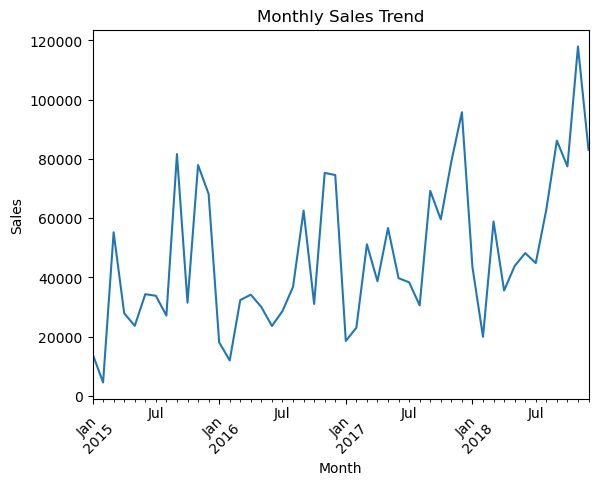

In [8]:
plt.figure()
monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

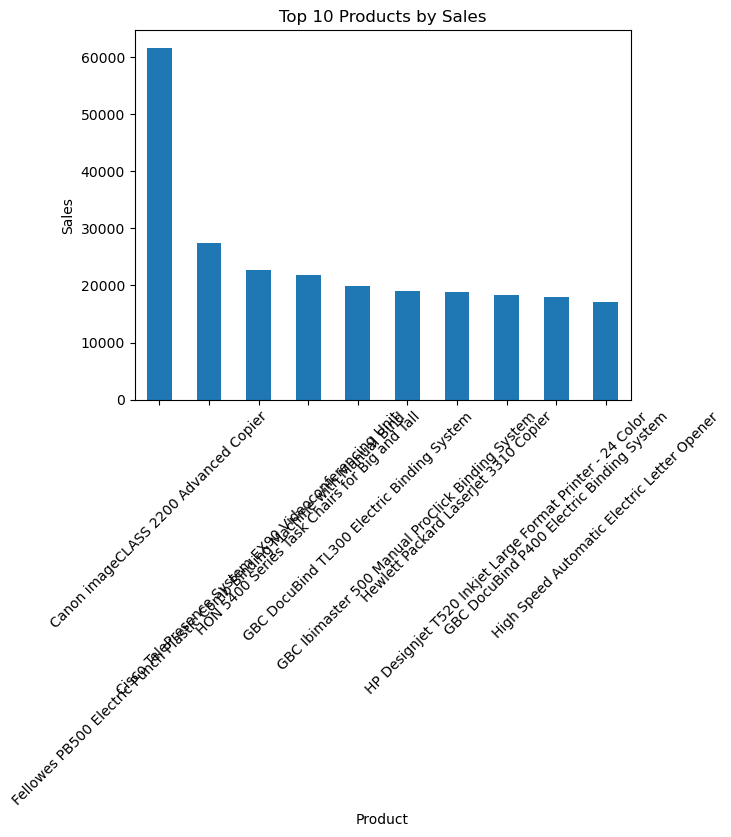

In [9]:
plt.figure()
top_products.head(10).plot(kind='bar')
plt.title("Top 10 Products by Sales")
plt.xlabel("Product")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

In [12]:
plt.figure()
region_sales.plot(kind='bar')
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.show()

NameError: name 'region_sales' is not defined

<Figure size 640x480 with 0 Axes>

In [13]:
# Save KPIs
summary = pd.DataFrame({
    "Metric": ["Total Revenue", "Average Order Value"],
    "Value": [total_revenue, avg_order_value]
})

summary.to_csv("sales_summary.csv", index=False)

# Save Top Products
top_products.head(10).to_csv("top_products.csv")

NameError: name 'total_revenue' is not defined

In [14]:
df.to_csv("cleaned_sales_data.csv", index=False)

========== KPI SUMMARY ==========
Total Revenue: 2260911.27
Average Order Value: 459.44

Sales by Region:
 Region
West       709618.1485
East       669494.7500
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64

Top 10 Products:
 Product_Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24 Color                       18374.895
GBC DocuBind P400 Elec

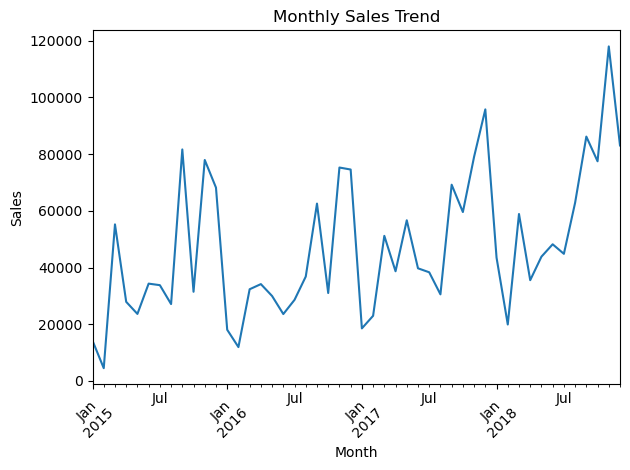

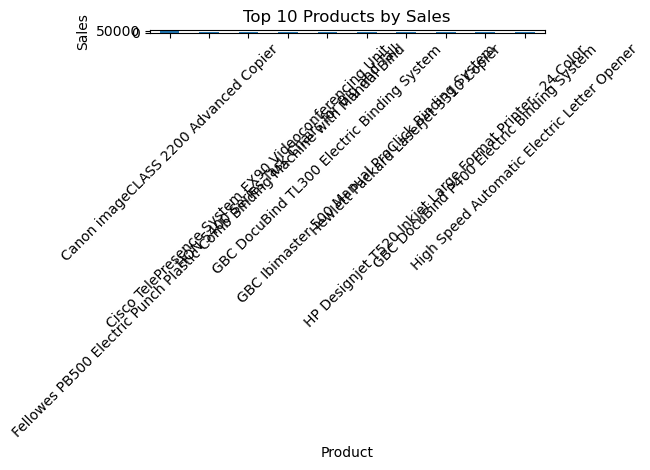

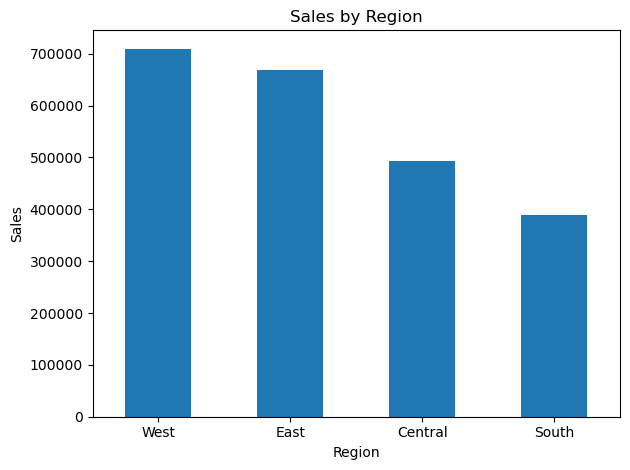


Files exported successfully:
- sales_summary.csv
- top_products.csv
- monthly_sales.csv
- cleaned_sales_data.csv
- Charts saved as PNG images


In [16]:
# ================================
# SALES DATA ANALYSIS SCRIPT
# ================================

# 1. Import Libraries
import pandas as pd
import matplotlib.pyplot as plt

# 2. Load Dataset
# Make sure your CSV file is in the same directory
file_path = "superstore_sales.csv"
df = pd.read_csv(file_path)

# 3. Data Cleaning
# ----------------

# Convert date columns (handles mixed formats)
df['Order_Date'] = pd.to_datetime(df['Order_Date'], errors='coerce', dayfirst=True)
df['Ship_Date'] = pd.to_datetime(df['Ship_Date'], errors='coerce', dayfirst=True)

# Ensure Sales is numeric
df['Sales'] = pd.to_numeric(df['Sales'], errors='coerce')

# Drop rows with critical missing values
df = df.dropna(subset=['Sales', 'Order_Date'])

# 4. Feature Engineering
# ----------------------
df['Month'] = df['Order_Date'].dt.to_period('M')

# 5. KPI Calculations
# -------------------
total_revenue = df['Sales'].sum()
avg_order_value = df.groupby('Order_ID')['Sales'].sum().mean()
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

# 6. Top Products
# ----------------
top_products = df.groupby('Product_Name')['Sales'].sum().sort_values(ascending=False)

# 7. Monthly Sales Trend
# ----------------------
monthly_sales = df.groupby('Month')['Sales'].sum()

# 8. Print Results
# ----------------
print("========== KPI SUMMARY ==========")
print(f"Total Revenue: {total_revenue:.2f}")
print(f"Average Order Value: {avg_order_value:.2f}")
print("\nSales by Region:\n", region_sales)

print("\nTop 10 Products:\n", top_products.head(10))

# 9. Visualizations
# -----------------

# Monthly Trend
plt.figure()
monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("monthly_sales_trend.png")
plt.show()

# Top Products
plt.figure()
top_products.head(10).plot(kind='bar')
plt.title("Top 10 Products by Sales")
plt.xlabel("Product")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("top_products.png")
plt.show()

# Sales by Region
plt.figure()
region_sales.plot(kind='bar')
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("sales_by_region.png")
plt.show()

# 10. Export Results
# ------------------

# KPI Summary
summary = pd.DataFrame({
    "Metric": ["Total Revenue", "Average Order Value"],
    "Value": [total_revenue, avg_order_value]
})
summary.to_csv("sales_summary.csv", index=False)

# Top Products
top_products.head(10).to_csv("top_products.csv")

# Monthly Sales
monthly_sales.to_csv("monthly_sales.csv")

# Cleaned Dataset
df.to_csv("cleaned_sales_data.csv", index=False)

print("\nFiles exported successfully:")
print("- sales_summary.csv")
print("- top_products.csv")
print("- monthly_sales.csv")
print("- cleaned_sales_data.csv")
print("- Charts saved as PNG images")

# ================================
# END OF SCRIPT
# ================================